In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import sklearn

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, OrdinalEncoder, StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, cross_val_predict, StratifiedKFold, RandomizedSearchCV

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier

from scipy.stats import randint as sp_randint
from scipy.stats import uniform

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay


In [2]:
# display all rows
# pd.set_option('display.max_rows', None)

# set random seed
np.random.seed(42)

In [3]:
# import data and take a look at few rows
original_df = pd.read_csv('train.csv')
original_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# check shape, null values and weight in case dtypes need to be changed .info()
original_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


The dataframe is light, there is no need to change Dtype of variables to make them lighter.

Some variables have null values. We can check how many of them exactly.

In [5]:
# Zoom in on null values
original_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
original_df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [7]:
# Make sure every row is a different observation and check how many different values each variable has
original_df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

Letter and number of cabin might relate to the location of the cabin, characteristics of the dweller or any other circumstance which could be related to the chances of survaving (maybe disable people where assigned a certain type of cabin and they were given priority to disembark regardless of their gender). I wonder if extracting the letter and number of cabin or only letter could be useful.

In [8]:
# split data into X and y
X = original_df.drop(columns=['PassengerId', 'Survived', 'Name', 'Ticket'])
y = original_df['Survived']

In [9]:
# keep a map of index vs PassengerId
passenger_id = original_df['PassengerId']

##  Set baseline-first development

### Transformations needed at this stage

Columns with missing values to be imputed:  
> Age (apply median and create a flag)  
> Cabin ('M' for missing)  
> Embarked
---
Columns to apply a function:  
> Cabin (extract code of cabin and recategorize G and T to M)
---
Categorical columns to be encoded:
> Pclass  
> Cabin  
> Embarked  

Inspect Cabin feature codes

In [10]:
# fill missing values, extract code and check value counts
X['Cabin'].fillna('M').str.extract(r'([A-Z])').value_counts()

0
M    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

Cabin feature:

There were 687 missing values, therefore, M is none of the extracted letters.

Values G and T don't have enough observations to keep a category (less than 1%), move them to the missing category

In [11]:
# check value counts of Embarked
X['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Embarked feature:

There are only 2 missing values. It's not enough to create another category. They should be assigned to the categorical mode.

#### Transform columns

In [12]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,male,22.0,1,0,7.2500,NaN,S
1,1,female,38.0,1,0,71.2833,C85,C
2,3,female,26.0,0,0,7.9250,NaN,S
3,1,female,35.0,1,0,53.1000,C123,S
4,3,male,35.0,0,0,8.0500,NaN,S


In [13]:
# Column Transformer is set to Pandas output (check bottom of cell) rather than np array in order to use Pandas str and replace methods


# transformer pipelines
cabin_transformer = Pipeline(steps=[
    ('imputer_c', SimpleImputer(strategy='constant', fill_value='M')),
    ('regex', FunctionTransformer(lambda x: x.iloc[:, 0].str.extract(r'([A-Z])', expand=True), feature_names_out='one-to-one')), # function transformers are not official so don't have a built in specified output name, this makes the transformer to output the input name if get_feature_names_out is used in the column transformer
    ('recategorize_GT', FunctionTransformer(lambda x: x.replace(['G', 'T'], 'M'), feature_names_out='one-to-one')), # same as above
    ('recategorize_DE', FunctionTransformer(lambda x: x.replace(['D', 'E'], 'DE'), feature_names_out='one-to-one')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

age_transformer = Pipeline(steps=[
    ('imputer_a', SimpleImputer(strategy='mean', add_indicator=True))
])

embarked_tranformer = Pipeline(steps=[
    ('imputer_e', SimpleImputer(strategy='constant', fill_value='S')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

sex_transformer = Pipeline(steps=[
    ('encoder', OrdinalEncoder())
])

pclass_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# column transformer
preprocessor = ColumnTransformer(
    transformers=(
        ('cabin', cabin_transformer, ['Cabin']),
        ('age', age_transformer, ['Age']),
        ('embarked', embarked_tranformer, ['Embarked']),
        ('sex', sex_transformer, ['Sex']),
        ('pclass', pclass_transformer, ['Pclass'])
    ),
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor.set_output(transform='pandas');

Check that intended transformations take place

In [14]:
# Uncomment the code below to confirm transformations

transformations_check = preprocessor.fit_transform(X)
# print(transformations_check.nunique())
# transformations_check

### Fit tree based models on the data

In [15]:
# create a dictionary of tree based models to try
tree_models = {
    'RandomForest':RandomForestClassifier(random_state=42),
    'ExtraTree':ExtraTreesClassifier(random_state=42),
    #'HistGradientBoosting':HistGradientBoostingClassifier(random_state=42),
    'XGB':XGBClassifier(),
    'CatBoost':CatBoostClassifier(random_state=42, verbose=0)
}

#### Using cross_val_score()

In [16]:
# work in progress
# create a variable to add the model scores (accuracy)
tree_scores = dict()

# create a list to add each model feature importance series
tree_feat_imp = dict()

# loop through the tree_models dictionary to fit the model
for name, model in tree_models.items():
    # model pipeline
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # instantiate the stratified k fold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # obtain cross validation scores
    result = cross_validate(clf, X, y, cv=cv, n_jobs=-1, return_train_score=True)

    # obtain test and train score means and add them to the distance models scores dictionary 
    test_mean = result['test_score'].mean()
    train_mean = result['train_score'].mean()
    tree_scores[name] = [test_mean, train_mean]

    # fit the model to obtain feature_importances
    clf.fit(X, y)
    
    # feed the feature importance list with feature importance series for each model but HistGradientBoosting
    if hasattr(clf['model'], 'feature_importances_'):        
        tree_feat_imp[name + '_v1'] = pd.Series(clf['model'].feature_importances_)


Model's scores

In [17]:
# convert scores dictionary into a dataframe
tree_scores = pd.DataFrame(tree_scores, index=['test mean_v1', 'train mean_v1']).T
tree_scores

,test mean_v1,train mean_v1
RandomForest,0.806917,0.987934
ExtraTree,0.783366,0.987934
XGB,0.827123,0.976429
CatBoost,0.839470,0.912458


Model's feature importance

In [18]:
# convert dictionary into a data frame
tree_feat_imp = pd.DataFrame(tree_feat_imp)

# add features names as index
tree_feat_imp.index = transformations_check.columns

# turn feature proportions into percentages (not needed for CatBoost)
tree_feat_imp[['RandomForest_v1', 'ExtraTree_v1', 'XGB_v1']] = tree_feat_imp[['RandomForest_v1', 'ExtraTree_v1', 'XGB_v1']] * 100
tree_feat_imp

,RandomForest_v1,ExtraTree_v1,XGB_v1,CatBoost_v1
Cabin_A,0.333927,0.258644,2.091494,0.367100
Cabin_B,0.559694,0.757363,1.439228,0.686543
Cabin_C,0.516158,0.504263,2.062366,0.911091
Cabin_DE,1.456311,1.438276,2.841038,2.340768
Cabin_F,0.247400,0.347327,0.000000,0.050379
Cabin_M,3.295684,3.294197,11.181120,3.476516
Age,23.250518,20.899272,2.304655,17.261217
missingindicator_Age,1.568960,1.590703,1.877829,1.193440
Embarked_C,1.575639,1.160944,1.559061,1.380074
Embarked_Q,0.822098,0.624335,0.821441,0.858689


### Second EDA

In [19]:
# review raw and unedited dataframe
original_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [20]:
# review dataframe modified after first EDA 
transformations_check

,Cabin_A,Cabin_B,Cabin_C,Cabin_DE,Cabin_F,Cabin_M,Age,missingindicator_Age,Embarked_C,Embarked_Q,Embarked_S,Sex,Pclass_1,Pclass_2,Pclass_3,SibSp,Parch,Fare
0,0.0,0.0,0.0,0.0,0.0,1.0,22.000000,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1,0,7.2500
1,0.0,0.0,1.0,0.0,0.0,0.0,38.000000,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0,71.2833
2,0.0,0.0,0.0,0.0,0.0,1.0,26.000000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0,0,7.9250
3,0.0,0.0,1.0,0.0,0.0,0.0,35.000000,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1,0,53.1000
4,0.0,0.0,0.0,0.0,0.0,1.0,35.000000,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0,0,8.0500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0.0,0.0,0.0,0.0,0.0,1.0,27.000000,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0,0,13.0000
887,0.0,1.0,0.0,0.0,0.0,0.0,19.000000,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0,0,30.0000
888,0.0,0.0,0.0,0.0,0.0,1.0,29.699118,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1,2,23.4500
889,0.0,0.0,1.0,0.0,0.0,0.0,26.000000,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0,0,30.0000


For a second EDA round, features that we need to use from the original dataframe are:
- Fare
- SibSp
- Parch
- Sex
- Pclass
- Survived (label)

Features needing transformation:
- Embarked (without encoding)
- Cabin (without encoding)
- Age (impute nulls)

Original required features

In [21]:
# grab needed features from the original dataframe
eda2_df = original_df.loc[:, ['Fare', 'SibSp', 'Parch', 'Sex', 'Pclass', 'Survived']]

Transform required features

In [22]:
# make a copy of the original pipeline
original_ohe = cabin_transformer.named_steps['onehot']

# change parameters to not encode features as last step 
cabin_transformer.set_params(onehot=None)
embarked_tranformer.set_params(onehot=None)


# instantiate the column transformer
eda2_pipe = ColumnTransformer(
    transformers=(
        ('eda2_cabin', cabin_transformer, ['Cabin']),
        ('eda2_embarked', embarked_tranformer, ['Embarked']),
        ('eda2_age', age_transformer, ['Age'])
    ),
    remainder='drop',
    verbose_feature_names_out=False,
    n_jobs=-1
)

# prevent the column transformer from converting data into an array (otherwise, it will convert all columns to the same dtype and numbers will become objects)
eda2_pipe.set_output(transform='pandas')

# fit model to data
eda2_arr = eda2_pipe.fit_transform(X)
eda2_columns = eda2_pipe.get_feature_names_out()
eda2_transformed_features = pd.DataFrame(eda2_arr, columns=eda2_columns)

# combine dataframes
eda2_df = pd.concat([eda2_transformed_features, eda2_df], axis=1).drop('missingindicator_Age', axis=1)

# activate back OneHotTransformation for cabin and embarked features for future transformations
cabin_transformer.set_params(onehot=original_ohe)
embarked_tranformer.set_params(onehot=original_ohe);



#### Visualize features

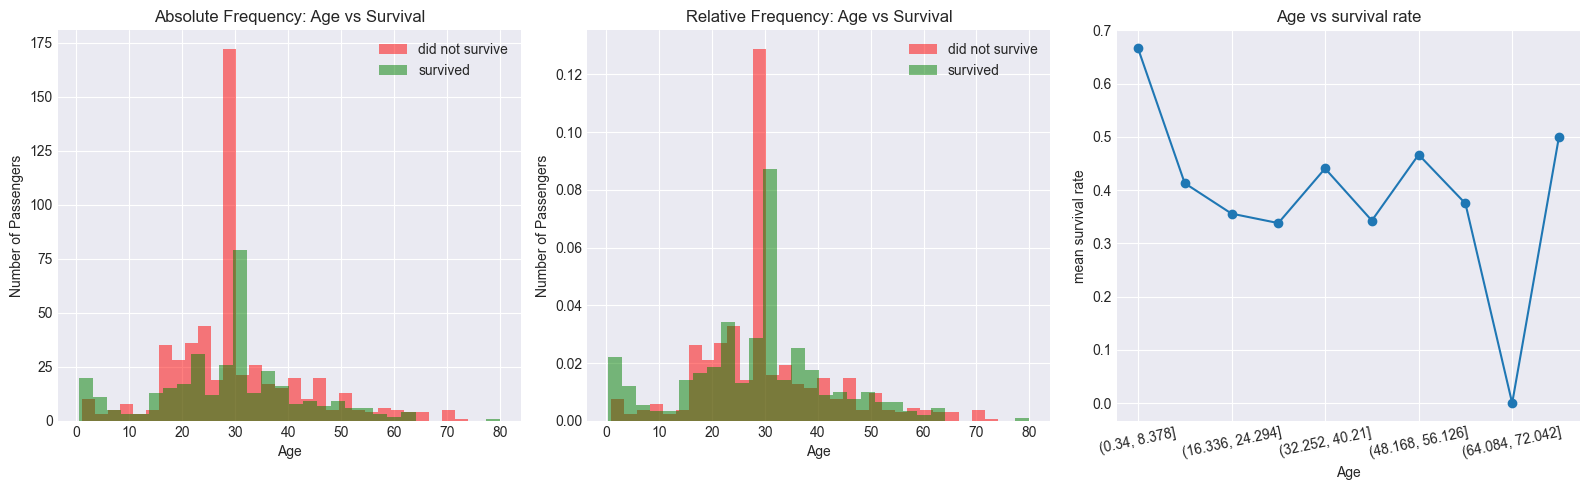

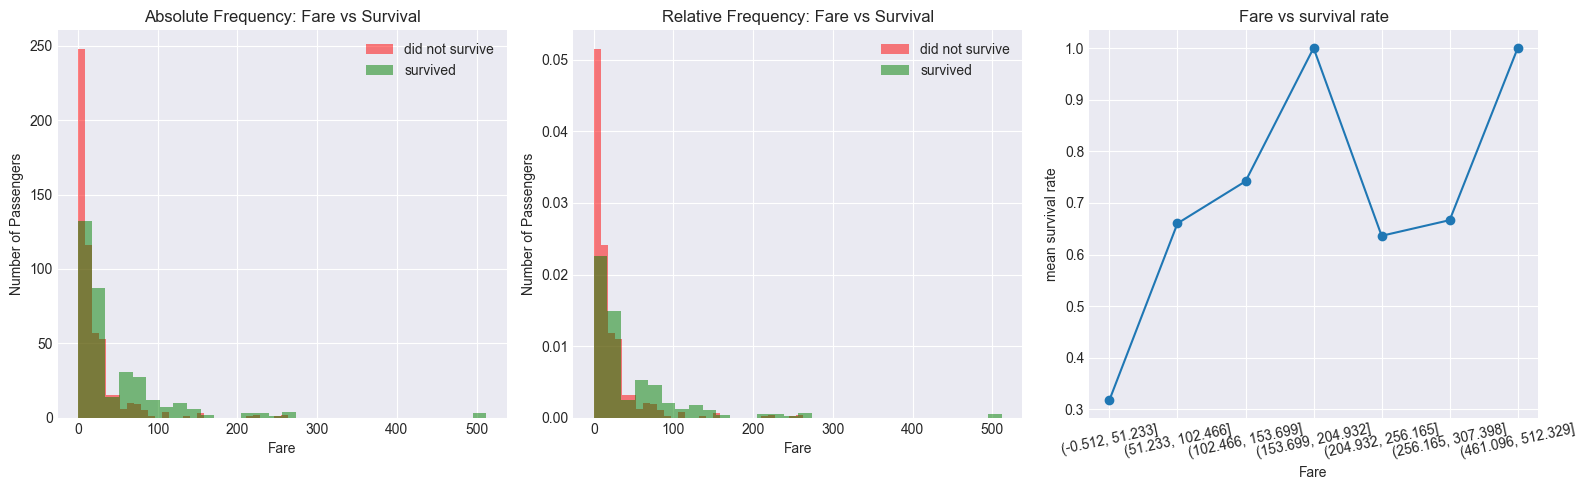

In [23]:
# split data into 2 dataframes, survived/did not survive to plot continuos features
eda2_df_1 = eda2_df[eda2_df['Survived'] == 1] # survived
eda2_df_0 = eda2_df[eda2_df['Survived'] == 0] # survived

# set plt style
plt.style.use('seaborn-v0_8-darkgrid')

# plot continuous features against survival
for feature in ['Age', 'Fare']:
    # Create a figure with 2 subplots (1 row, 2 columns)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

    for ax, density, frequency in ((ax1, False, 'Absolute'), (ax2, True, 'Relative')):

        ax.hist(eda2_df_0[feature], bins=30, alpha=0.5, color='red', label='did not survive', density=density)
        ax.hist(eda2_df_1[feature], bins=30, alpha=0.5, color='green', label='survived', density=density)
        ax.set_title(f'{frequency} Frequency: {feature} vs Survival')
        ax.set_ylabel('Number of Passengers')
        ax.set_xlabel(feature)
        ax.legend()

    # bin continuous feature into intervals and get mean survival rate
    feature_interval = eda2_df.groupby(pd.cut(eda2_df[feature], 10))['Survived'].mean()
    feature_interval.plot(kind='line', marker='o',ax=ax3, ylabel='mean survival rate', title=f'{feature} vs survival rate')
    # Rotates labels 45 degrees for better readability
    ax3.tick_params(axis='x', labelrotation=12)
   

    plt.tight_layout() # Prevents labels from overlapping
    plt.show()

#### Plots comments

Age vs survival: It seems that the probability of surviving for children under 10 was higher. The peak around 30 is caused by the imputed values.

Fare vs survival: Low fares seem to correspond with lower chance of surviving. From roughly 50$ the rate of survival increases.

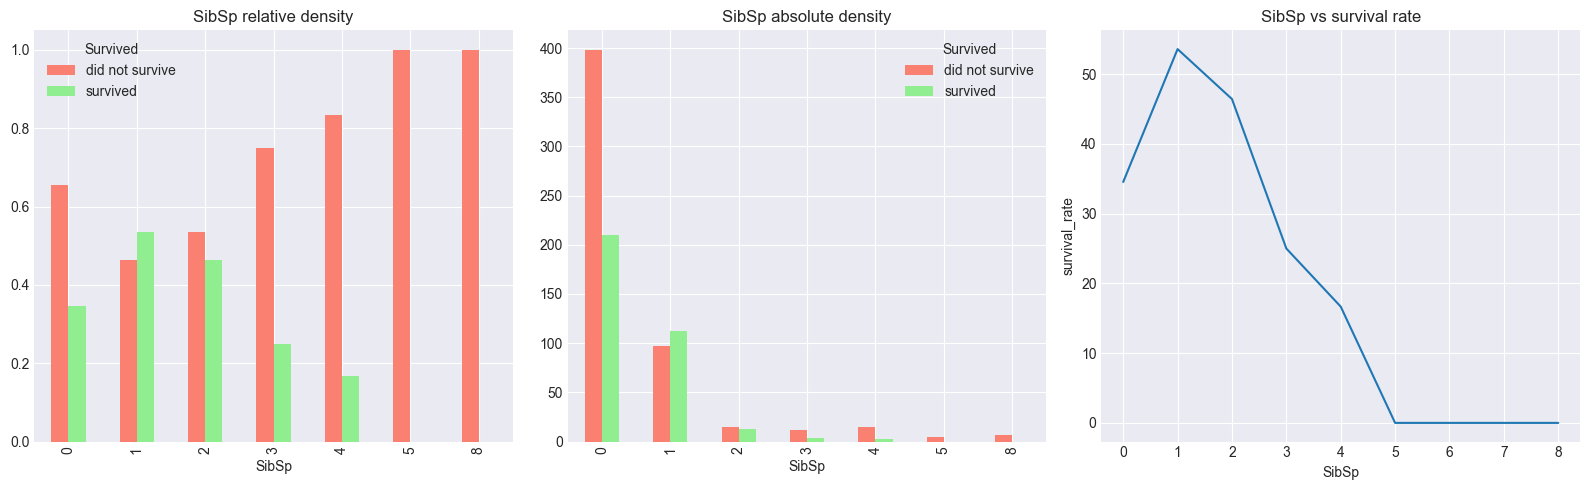

Survived,did not survive,survived,survival_rate
SibSp,,,
0,398,210,34.54
1,97,112,53.59
2,15,13,46.43
3,12,4,25.00
4,15,3,16.67
5,5,0,0.00
8,7,0,0.00


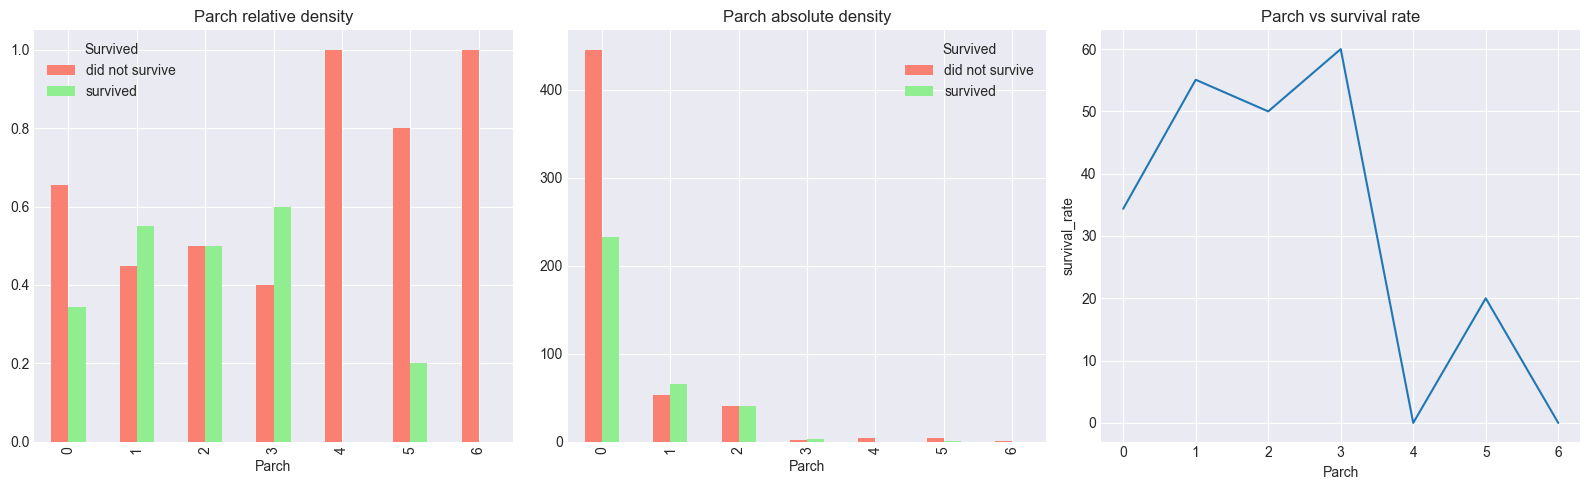

Survived,did not survive,survived,survival_rate
Parch,,,
0,445,233,34.37
1,53,65,55.08
2,40,40,50.00
3,2,3,60.00
4,4,0,0.00
5,4,1,20.00
6,1,0,0.00


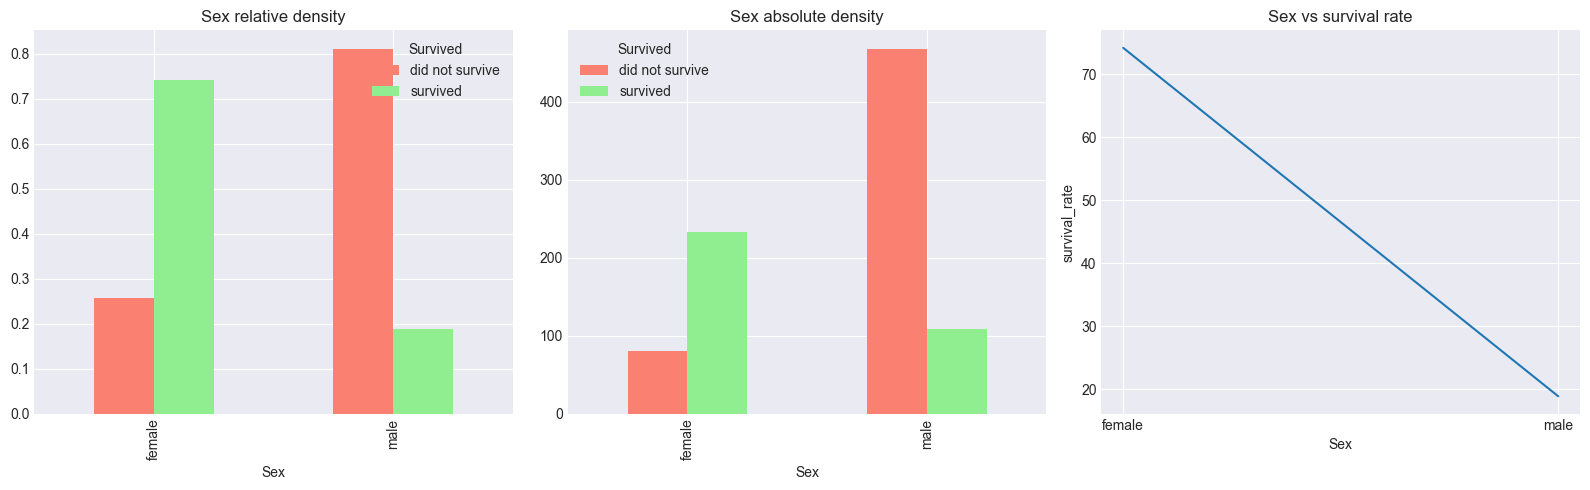

Survived,did not survive,survived,survival_rate
Sex,,,
female,81,233,74.20
male,468,109,18.89


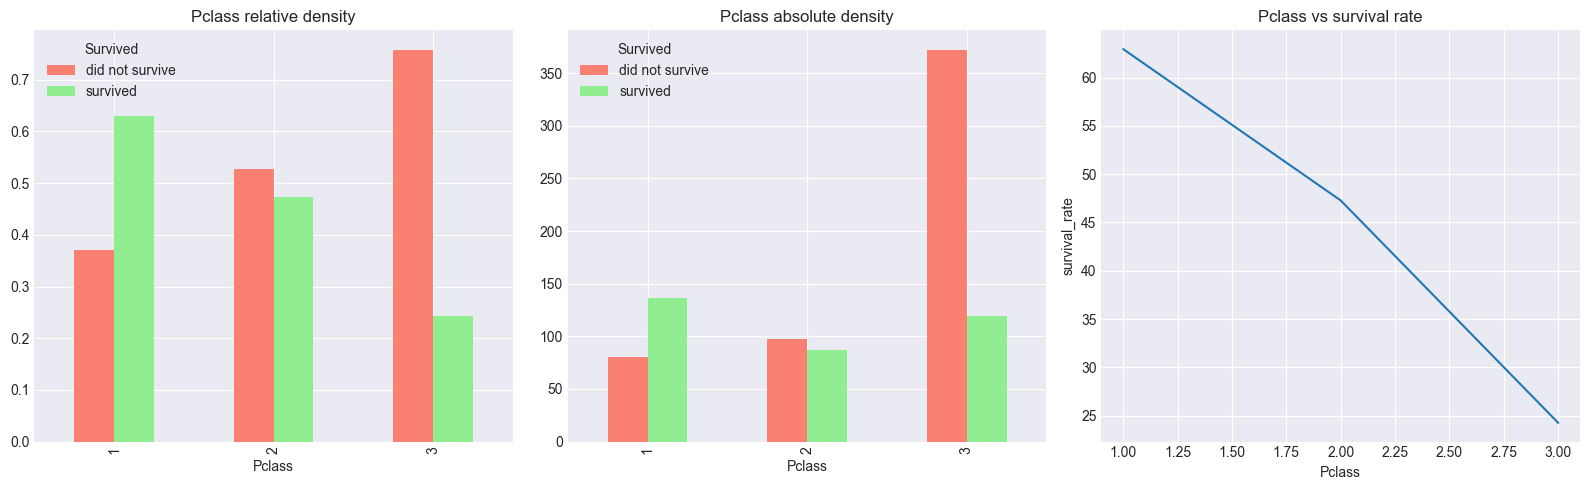

Survived,did not survive,survived,survival_rate
Pclass,,,
1,80,136,62.96
2,97,87,47.28
3,372,119,24.24


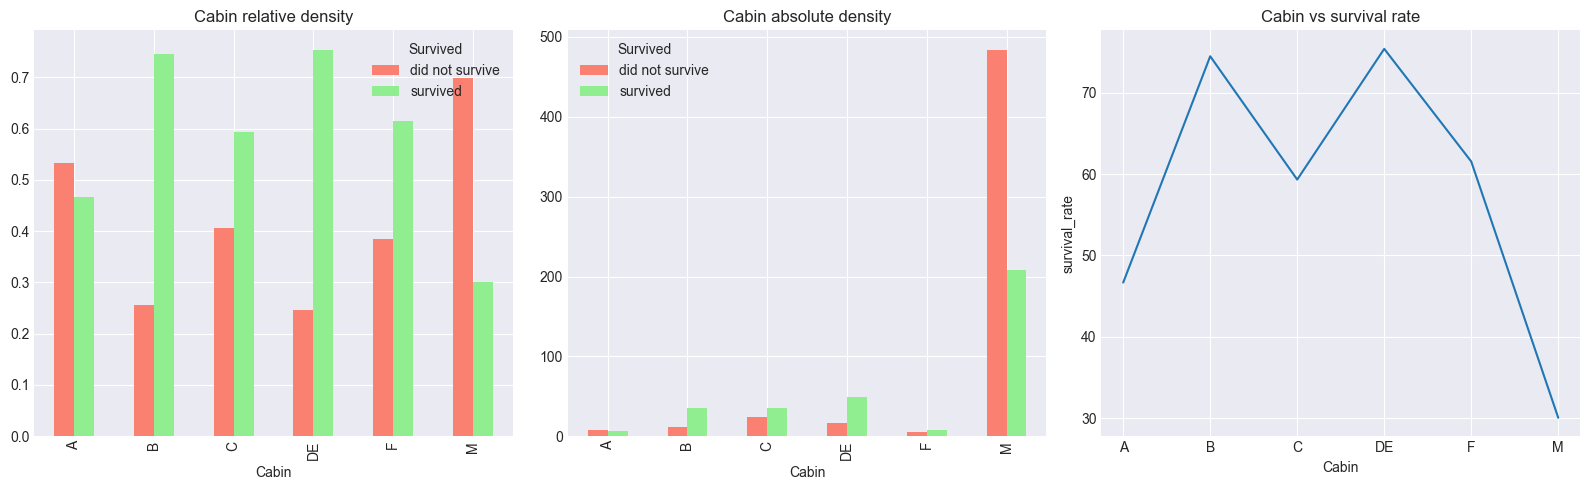

Survived,did not survive,survived,survival_rate
Cabin,,,
A,8,7,46.67
B,12,35,74.47
C,24,35,59.32
DE,16,49,75.38
F,5,8,61.54
M,484,208,30.06


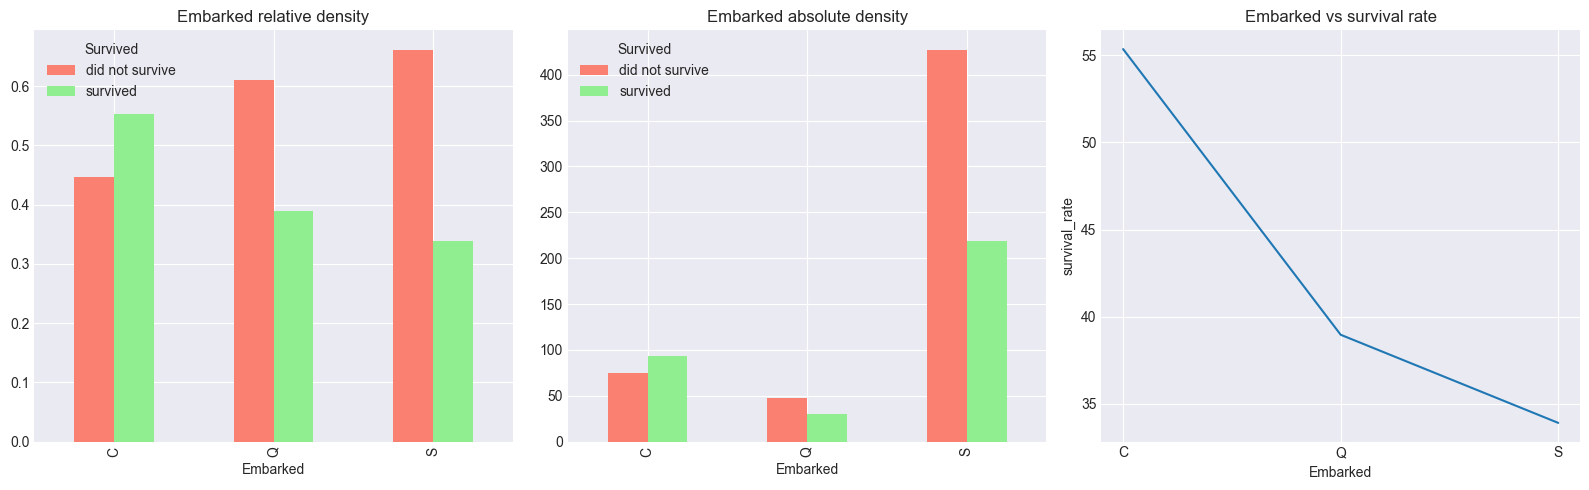

Survived,did not survive,survived,survival_rate
Embarked,,,
C,75,93,55.36
Q,47,30,38.96
S,427,219,33.90


In [24]:
# plot discrete features against survival
discrete_features = ['SibSp', 'Parch', 'Sex', 'Pclass', 'Cabin', 'Embarked']
for feature in discrete_features:
    # instantiate figure object
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

    for type, axis, is_relative in (('index', ax1, 'relative'), (False, ax2, 'absolute')):            
        ct = pd.crosstab(eda2_df[feature], eda2_df['Survived'], normalize=type)
        ct.rename(columns= {0:'did not survive', 1: 'survived'},
        inplace=True)       

        ct[['did not survive', 'survived']].plot(kind='bar',
            ax=axis,
            color=['salmon', 'lightgreen'],            
            title=f'{feature} {is_relative} density'
            )  
        
    # add a survival rate column in the cross-table
    ct['survival_rate'] = ((ct['survived'] / ct.sum(axis=1)) * 100).round(2)
    ax3.plot(ct['survival_rate'])
    ax3.set(title=f'{feature} vs survival rate',            
            xlabel=feature,
            ylabel='survival_rate')

    
    plt.tight_layout()
    plt.show()
    display(ct)

#### Plots comments

SibSp: Passengers with one or two sibling/spouse where roughly equally likeable to survive/not survive. All other combinations where more likely to not survive. Check number of observations per group, it might be convinient to make a group over 3 or 4 sibsp. I was inclined to group SibSp observations above a value 0f 2, however, I find it significant that out of 13 cases, none survived above 4. Clip it at 5.

Parch: Passengers with one, two or three parent/children where roughly equally likeable to survive/not survive. All other combinations where more likely to not survive. Check number of observations per group, it might be convinient to make a group over 4 parch. Clip it at 4.

Sex: Females had a higher probability of survival.

Pclass: The probability of survival was highest among class 1. Class 2 has roughly the same probability between survive/did not survive. Class 3 had the lowest probability of survival, passengers were 3.5 times more likely to not survive than survive in that class.

Cabin: Cabins A and F have roughly the same survival rate. The missing category has the lowest survival rate. All other cabins have a positive survival rate. Group cabins D and E.

Embarked: C has a mild positive survival rate and Q a mild negative one. S survival rate is the lowest, roughly a third.

#### Plot histograms

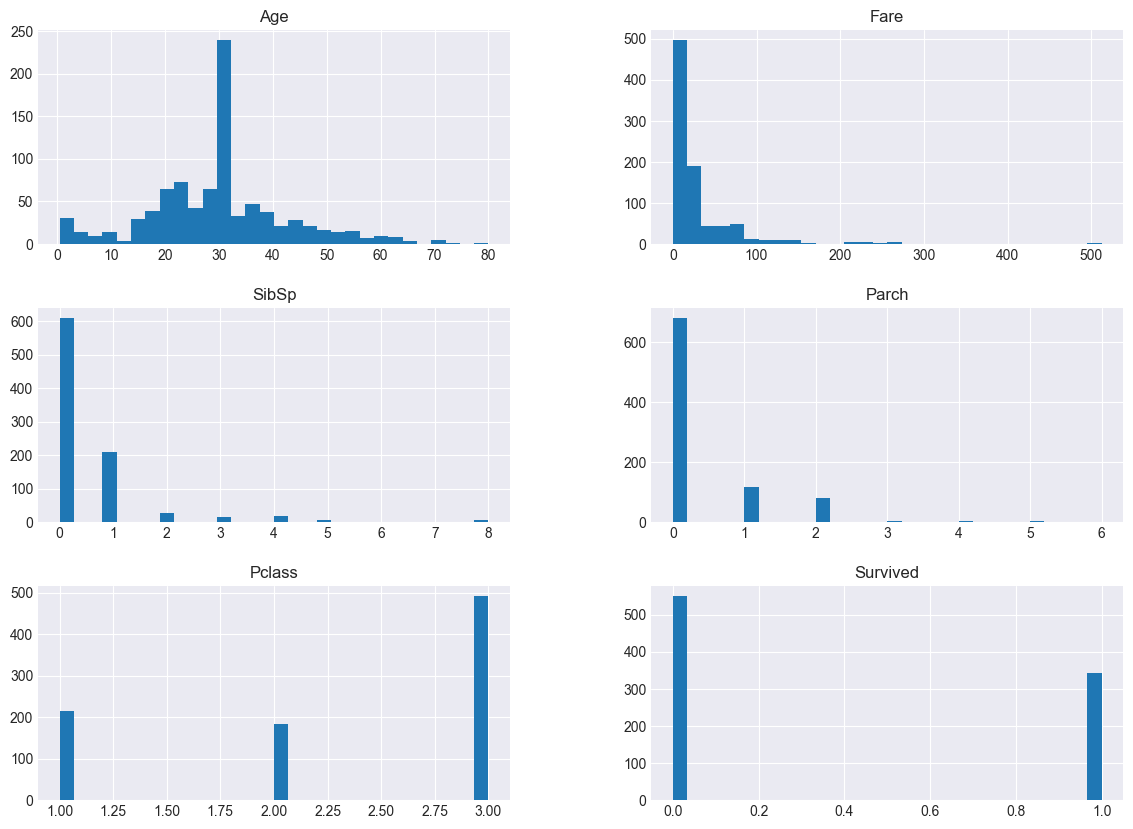

In [25]:
# quick histogram of numeric features
eda2_df.hist(figsize=(14,10), bins=30);

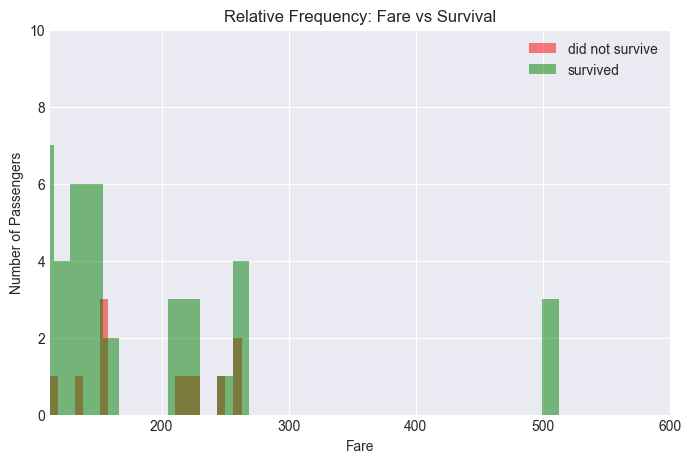

In [26]:
# zoom in on the tail of Fare feature to determine whether to clip outliers

# determine the required quantile
quantile = eda2_df['Fare'].quantile(0.95)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(eda2_df_0['Fare'], bins=40, alpha=0.5, color='red', label='did not survive')
ax.hist(eda2_df_1['Fare'], bins=40, alpha=0.5, color='green', label='survived')
ax.set_title('Relative Frequency: Fare vs Survival')
ax.set_ylabel('Number of Passengers')
ax.set_xlabel('Fare')
ax.set(xlim=(quantile, 600),
       ylim=(0, 10))
ax.legend()

plt.show()

We can either cap it at 95th or 99th quantile and apply a log transformation or only apply the log transformation

#### Linear correlation between variables

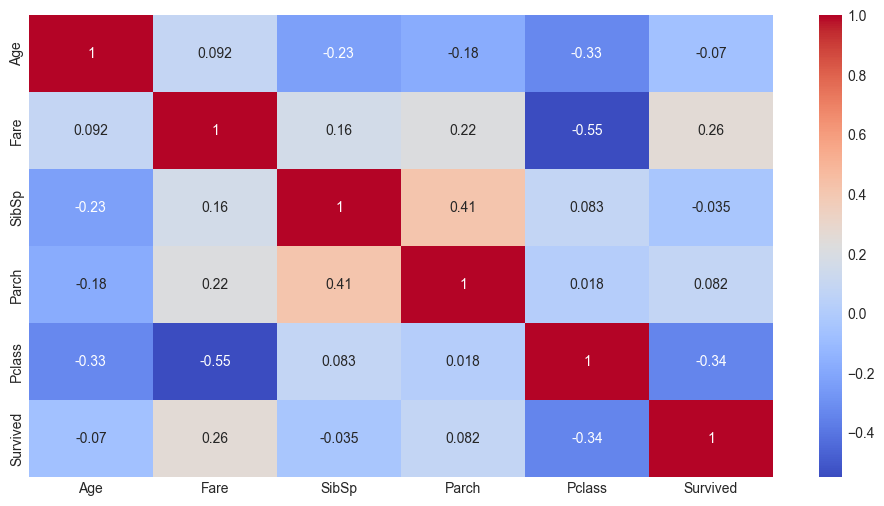

In [27]:
# only numeric features dataframe 
eda2_df_numeric = eda2_df.loc[:, ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'Survived']]

# build correlation matrix
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(eda2_df_numeric.corr(), annot=True, cmap='coolwarm', ax=ax)
plt.show()

#### Scatterplot continuous variables

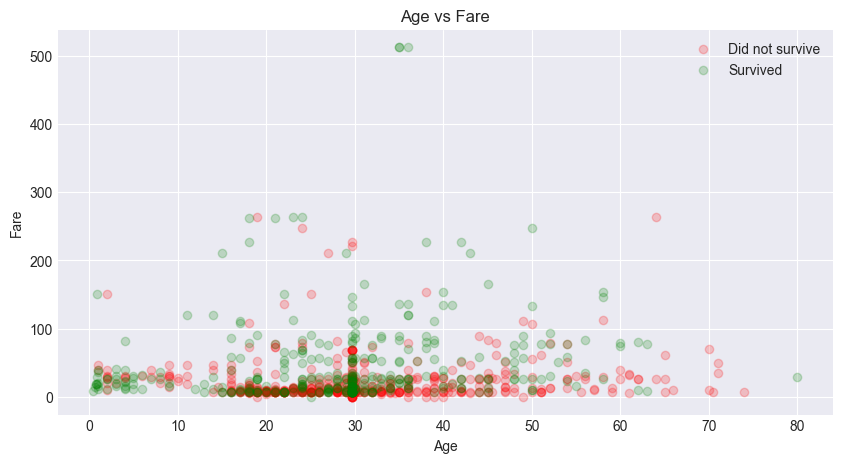

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(eda2_df_0['Age'], eda2_df_0['Fare'], color='red', alpha=0.2)
ax.scatter(eda2_df_1['Age'], eda2_df_1['Fare'], color='green', alpha=0.2)

ax.set(title='Age vs Fare',
       xlabel='Age',
       ylabel='Fare')

plt.legend(['Did not survive', 'Survived'])
plt.show()

#### Transformations to apply  
- age: Standardize  

- Fare: Apply log transformation and standardize (done by default by yeo-johnson)

- SibSp: Clip at 5 and standardize 

- Parch: Clip at 4 and standardize  

- Pclass: One hot encode  

- Cabin: Group cabins D and E (on first transformation)  and One hot encode

In [29]:
# sibsp feature transformer pipeline
sibsp_transformer = Pipeline(steps=[
    ('clip_sibsp', FunctionTransformer(lambda x: x.clip(upper=5), feature_names_out='one-to-one')),
    ('standard', StandardScaler())
])

# parch feature transformer pipeline
parch_transformer = Pipeline(steps=[
    ('clip_parch', FunctionTransformer(lambda x: x.clip(upper=4), feature_names_out='one-to-one')),
    ('standard', StandardScaler())
])

preprocessor_v2 = ColumnTransformer(
    transformers=(
        ('age', StandardScaler(), ['Age']),
        ('fare', PowerTransformer(), ['Fare']),
        ('sibsp', sibsp_transformer, ['SibSp']),
        ('parch', parch_transformer, ['Parch'])
    ),
    remainder='passthrough',
    verbose_feature_names_out=False,
    n_jobs=-1
)

# set the output of each step as dataframe
preprocessor_v2.set_output(transform='pandas');

In [30]:
transform_pipeline_v2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('preprocessor_v2', preprocessor_v2),    
    ])

# transform data
transformed_df_v2 = transform_pipeline_v2.fit_transform(X)

# obtain column names
transformed_df_v2.columns = transform_pipeline_v2.get_feature_names_out()

# display transformed dataframe
transformed_df_v2.head()

,Age,Fare,SibSp,Parch,Cabin_A,Cabin_B,Cabin_C,Cabin_DE,Cabin_F,Cabin_M,missingindicator_Age,Embarked_C,Embarked_Q,Embarked_S,Sex,Pclass_1,Pclass_2,Pclass_3
0,-0.592481,-0.878820,0.518395,-0.489905,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
1,0.638789,1.336651,0.518395,-0.489905,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.284663,-0.790065,-0.517233,-0.489905,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.407926,1.067352,0.518395,-0.489905,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.407926,-0.774439,-0.517233,-0.489905,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0


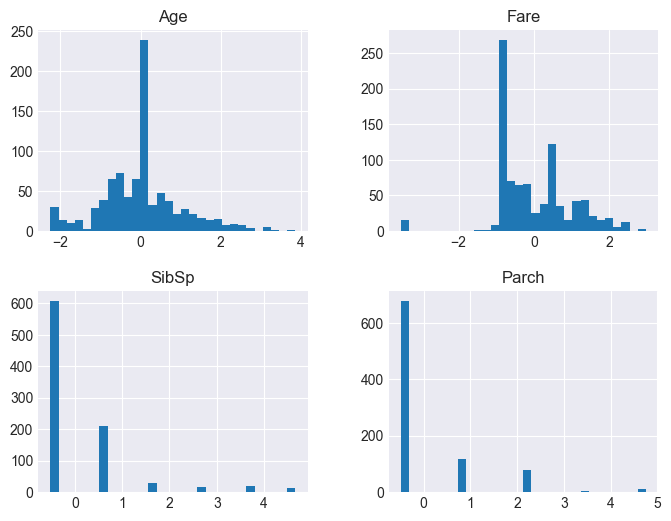

In [31]:
# plot transformed features age, Fare, sibsp and parch
transformed_df_v2.iloc[:,:4].hist(figsize=(8, 6), bins=30);

### Implement cross validation for distance based algorithms

In [32]:
# dictionary of models
distance_models = {'Linear SVC':LinearSVC(random_state=42),
        'SVC svm linear kernel':SVC(kernel='linear', random_state=42),
        'SVC svm rbf kernel':SVC(random_state=42),          
        'Kneighbours':KNeighborsClassifier(),
        'Logistic regression':LogisticRegression(solver='liblinear', max_iter=2000, random_state=42),
        'Linear regression':LinearRegression(),
        'GaussianNB':GaussianNB(),
        'SGDClassifier':SGDClassifier(random_state=42)
         }

In [33]:
# create a dictionary to add the model scores (accuracy)
dist_scores = dict()

# create a dictionary to add each model feature importance
dist_feat_imp = dict()

# loop through the tree_models dictionary to fit the model
for name, model in distance_models.items():
    # model pipeline
    clf = Pipeline(steps=[
        ('transform_pipeline_v2', transform_pipeline_v2),        
        (name, model)
    ])

    # instantiate the stratified k fold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # obtain cross validation scores
    result = cross_validate(clf, X, y, cv=cv, n_jobs=-1, return_train_score=True)

    # obtain test and train score means and add them to the distance models scores dictionary 
    test_mean = result['test_score'].mean()
    train_mean = result['train_score'].mean()
    dist_scores[name] = [test_mean, train_mean]
    
    # obtain feature importance 
    clf.fit(X, y)

    if hasattr(model, "coef_"):
        coefs = clf[name].coef_.flatten()
        dist_feat_imp[name] = pd.Series(coefs, index=transformed_df_v2.columns)

In [34]:
# convert the scores dictionary into a dataframe
dist_scores = pd.DataFrame(dist_scores, index=['test mean_v1', 'train mean_v1']).T
dist_scores

,test mean_v1,train mean_v1
Linear SVC,0.797991,0.819023
SVC svm linear kernel,0.778890,0.792927
SVC svm rbf kernel,0.821524,0.847080
Kneighbours,0.785626,0.849326
Logistic regression,0.805838,0.820705
Linear regression,0.390335,0.418134
GaussianNB,0.713797,0.724187
SGDClassifier,0.776643,0.778054


In [35]:
# convert the feature importance into a DataFrame, normalize them and display them as percentage
dist_feat_imp = pd.DataFrame(dist_feat_imp)
dist_feat_imp = (dist_feat_imp.abs()
                .div(dist_feat_imp.abs()
                .sum(axis=0), axis=1) * 100).round(2)
dist_feat_imp

,Linear SVC,SVC svm linear kernel,Logistic regression,Linear regression,SGDClassifier
Age,5.11,0.00,5.52,5.45,7.35
Fare,3.35,0.00,4.22,3.77,2.00
SibSp,3.86,0.01,4.21,3.97,4.37
Parch,1.41,0.00,1.50,1.45,0.03
Cabin_A,3.61,5.00,2.42,2.53,4.21
Cabin_B,3.11,5.00,3.73,0.47,2.10
Cabin_C,2.50,5.00,2.23,4.94,2.10
Cabin_DE,9.34,24.99,9.20,7.32,4.21
Cabin_F,4.54,4.99,4.23,4.16,2.10
Cabin_M,6.30,5.00,6.04,9.55,14.73


In [36]:
# rank by test accuracy score all models (tree and distance based)
models_rank = (pd.concat([tree_scores, dist_scores], axis=0)
              .sort_values(by='test mean_v1', ascending=False))
models_rank

,test mean_v1,train mean_v1
CatBoost,0.839470,0.912458
XGB,0.827123,0.976429
SVC svm rbf kernel,0.821524,0.847080
RandomForest,0.806917,0.987934
Logistic regression,0.805838,0.820705
Linear SVC,0.797991,0.819023
Kneighbours,0.785626,0.849326
ExtraTree,0.783366,0.987934
SVC svm linear kernel,0.778890,0.792927
SGDClassifier,0.776643,0.778054


### Hyperparameter Tunning

In [37]:
param_grid = {
    'Logistic regression': {
        'C': uniform(0.01, 10),              # Strength of regularization
        #'penalty': ['l1', 'l2'],            # Type of regularization
        'l1_ratio': [0, 1],            
        'solver': ['liblinear']              # Required for l1 penalty
    },

    'Linear SVC': {
        'C': uniform(0.1, 10),
        'max_iter': sp_randint(1000, 5000),  # Ensures the model has time to find a solution
        'tol': [1e-4, 1e-3, 1e-2]            # Tolerance for stopping criteria
    },

    'SVC svm rbf kernel': {
        'C': uniform(0.1, 10),
        'gamma': uniform(0.001, 1),          # Controls the influence of individual points
        'kernel': ['rbf']
    },

    'RandomForest': {
        'n_estimators': sp_randint(100, 1000),
        'max_depth': [None, 5, 8, 10, 15, 20],
        'max_features': ['sqrt', 'log2', None],
        'min_samples_split': sp_randint(2, 20), # Higher values = less overfitting
        'min_samples_leaf': sp_randint(1, 10),   # Higher values = smoother model
        'bootstrap': [True, False]
    },

    'XGB': {
        'n_estimators': sp_randint(100, 1000),
        'learning_rate': uniform(0.01, 0.3),    # Smaller = more robust, but needs more trees
        'max_depth': sp_randint(3, 10),        # High depth causes the overfitting you see
        'subsample': uniform(0.6, 0.4),         # Use only 60-100% of data per tree
        'colsample_bytree': uniform(0.6, 0.4),  # Use only 60-100% of features per tree
        'gamma': uniform(0, 5)                  # Minimum loss reduction to split
    },

    'CatBoost': {
        'iterations': sp_randint(100, 1000),
        'depth': sp_randint(4, 10),
        'learning_rate': uniform(0.01, 0.3),
        'l2_leaf_reg': sp_randint(1, 10),       # High values prevent overfitting
        'border_count': sp_randint(32, 255)     # Number of splits for numerical features
    }
}

In [38]:
random_search_results_dict = {}
random_search_best_scores = {}

# loop through the chosen algorithms
for model_name, param in param_grid.items():
    
    # add model__ to access the model's hyperparameters within the pipeline
    pipe_param = {f'model__{k}': v for k, v in param.items()}
    
    # fit tree-based algorithms
    if model_name in tree_models: 
        clf = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', tree_models[model_name])
        ])
    
    # fit non tree-based algorithms
    elif model_name in distance_models:
        clf = Pipeline(steps=[
            ('transform_pipeline_v2', transform_pipeline_v2),
            ('model', distance_models[model_name])
        ])


    # setup stratified kfold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # setup randomizedSearchCV
    n_iter = 10
    rs = RandomizedSearchCV(estimator=clf,
                            param_distributions=pipe_param,
                            random_state=42, 
                            n_iter=n_iter,
                            cv=cv,
                            n_jobs=-1,
                            return_train_score=True)
    
    rs.fit(X, y)

    random_search_results_dict[model_name] = {
        'best_estimator':rs.best_estimator_,
        'cv_results':rs.cv_results_,
        'best_params':rs.best_params_}
    random_search_best_scores[model_name] = rs.best_score_


In [39]:
# inspect cv results sorted by mean test score, drop unnecessary information
columns_to_drop = ['params', 'mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'split0_train_score',	'split1_train_score', 'split2_train_score', 'split3_train_score', 'split4_train_score', 'std_train_score', 'rank_test_score']

for key, value in random_search_results_dict.items():
    print('---')
    print(key)
    df = (pd.DataFrame(value['cv_results'])
          .sort_values(by='rank_test_score')
          .drop(columns=columns_to_drop)
          [:5].reset_index(drop=True).T)
    display(df)

---
Logistic regression


,0,1,2,3,4
param_model__C,0.590836,0.574116,3.755401,5.996585,4.468328
param_model__l1_ratio,1,1,0,0,0
param_model__solver,liblinear,liblinear,liblinear,liblinear,liblinear
mean_test_score,0.804708,0.804708,0.80359,0.802473,0.802473
std_test_score,0.025015,0.025015,0.024876,0.024937,0.024937
mean_train_score,0.816215,0.816216,0.820425,0.820705,0.820706


---
Linear SVC


,0,1,2,3,4
param_model__C,0.170663,0.680836,0.305845,3.845401,6.111150
param_model__max_iter,3904.000000,3135.000000,1769.000000,1860.000000,4735.000000
param_model__tol,0.000100,0.000100,0.001000,0.010000,0.010000
mean_test_score,0.802479,0.800232,0.800232,0.797991,0.797991
std_test_score,0.027070,0.024701,0.027368,0.027429,0.027429
mean_train_score,0.818463,0.819023,0.819023,0.819303,0.819584


---
SVC svm rbf kernel


...

,0,1,2,3,4
param_model__bootstrap,False,False,False,False,True
param_model__max_depth,8,8,20,20,5
param_model__max_features,log2,log2,sqrt,log2,NaN
param_model__min_samples_leaf,1,5,9,2,7
param_model__min_samples_split,5,3,18,2,13
param_model__n_estimators,661,443,574,559,608
mean_test_score,0.836118,0.835001,0.829408,0.829389,0.828253
std_test_score,0.020982,0.017029,0.018635,0.019129,0.027356
mean_train_score,0.910212,0.876823,0.865038,0.941077,0.862513


---
XGB


,0,1,2,3,4
param_model__colsample_bytree,0.844741,0.872123,0.724684,0.847354,0.843999
param_model__gamma,0.697469,2.252496,2.600340,1.912310,4.165975
param_model__learning_rate,0.097643,0.013979,0.174013,0.304969,0.062009
param_model__max_depth,9.000000,3.000000,8.000000,3.000000,3.000000
param_model__n_estimators,289.000000,415.000000,576.000000,230.000000,661.000000
param_model__subsample,0.636243,0.825315,0.987834,0.943976,0.865009
mean_test_score,0.838334,0.831618,0.831605,0.829377,0.828247
std_test_score,0.035052,0.023757,0.031960,0.025186,0.020531
mean_train_score,0.934904,0.860268,0.865882,0.865878,0.848764


---
CatBoost


,0,1,2,3,4
param_model__border_count,134.000000,89.000000,119.000000,95.000000,91.000000
param_model__depth,5.000000,9.000000,8.000000,4.000000,9.000000
param_model__iterations,566.000000,352.000000,199.000000,230.000000,341.000000
param_model__l2_leaf_reg,7.000000,9.000000,8.000000,5.000000,9.000000
param_model__learning_rate,0.027425,0.097369,0.222422,0.192263,0.014790
mean_test_score,0.841730,0.834976,0.832754,0.832741,0.828241
std_test_score,0.021861,0.038503,0.022141,0.020435,0.026229
mean_train_score,0.910492,0.975869,0.909932,0.951456,0.900671


In [40]:
# compare first model fitting of tree and non-tree models test and train scores with the randomized search score
random_search_best_scores = pd.Series(random_search_best_scores, name='rs test mean')
models_rank = pd.concat([models_rank[:6], random_search_best_scores], axis=1)
models_rank

,test mean_v1,train mean_v1,rs test mean
CatBoost,0.839470,0.912458,0.841730
XGB,0.827123,0.976429,0.838334
SVC svm rbf kernel,0.821524,0.847080,0.822641
RandomForest,0.806917,0.987934,0.836118
Logistic regression,0.805838,0.820705,0.804708
Linear SVC,0.797991,0.819023,0.802479


### Model evaluation


Since CatBoost is the top performer, we will analyze its results. Because the fitted best_estimator_ instance can trigger a RuntimeError when cloned by Scikit-Learn, we will re-initialize the model using the best hyperparameters to perform our cross-validated evaluation.

In [41]:
# get the hyperparameters and remove the pipeline prefix
best_catboost_params = random_search_results_dict['CatBoost']['best_params']
best_catboost_params = {k.replace('model__', ''):v for k, v in best_catboost_params.items()}
best_catboost_params.pop('learning_rate', None)

# instantiate a new CatBoost with the best hyperparameters
best_catboost_mod = CatBoostClassifier(**best_catboost_params)

# build pipeline to preprocess data
catboost_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_catboost_mod)
])

# stratify data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# make cross validation prediction
catboost_preds = cross_val_predict(catboost_pipeline, X, y, cv=cv, n_jobs=-1)

# make cross validation prediction
catboost_probs = cross_val_predict(catboost_pipeline, X, y, cv=cv, n_jobs=-1, method='predict_proba')

##### Classification report

In [42]:
print(classification_report(y, catboost_preds))

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       549
           1       0.84      0.73      0.78       342

    accuracy                           0.84       891
   macro avg       0.84      0.82      0.83       891
weighted avg       0.84      0.84      0.84       891



The model is significantly good at spotting people who died but it's missing 27% of the survivours. It only predicts 1 if it is very sure.

Investigate the false negatives against the true positives to improve the model.

#### Confusion matrix

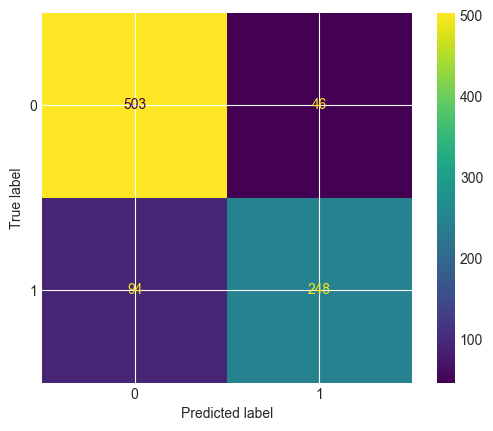

In [43]:
ConfusionMatrixDisplay.from_predictions(y, catboost_preds);

#### ROC curve

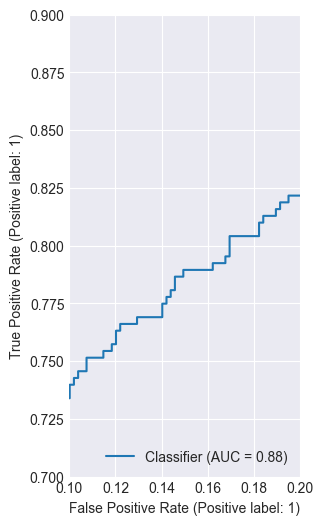

In [44]:
fig, ax = plt.subplots(figsize=(8, 6))

viz_roc = RocCurveDisplay.from_predictions(y, catboost_probs[:,1], ax=ax);
viz_roc.ax_.set(xlim=(0.1, 0.2),
                ylim=(0.7, 0.9));

#### Plotting PR curve (precision and recall against the threshold)

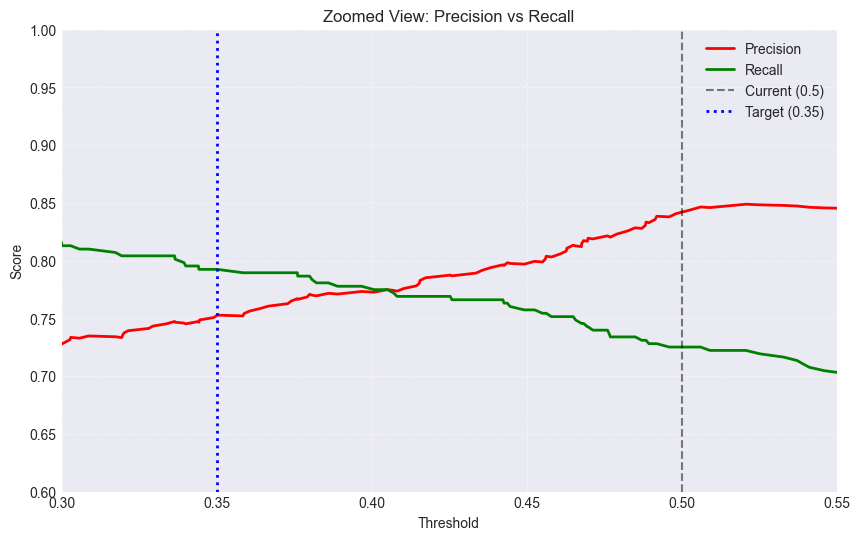

In [45]:
# 1. Get the raw arrays
precision, recall, thresholds = precision_recall_curve(y, catboost_probs[:, 1])

# 2. Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label="Precision", color="red", lw=2)
plt.plot(thresholds, recall[:-1], label="Recall", color="green", lw=2)

# 3. Add a vertical line at 0.5 (current) and 0.35 (target)
plt.axvline(0.5, color='black', linestyle='--', alpha=0.5, label='Current (0.5)')
plt.axvline(0.35, color='blue', linestyle=':', lw=2, label='Target (0.35)')

# 4. THE ZOOM: Adjust these numbers to focus where you want
plt.xlim(0.3, 0.55)  # Focusing around the 0.35 - 0.5 range
plt.ylim(0.6, 1.0)  # Zooming in on the high-performance area

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Zoomed View: Precision vs Recall")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

#### Analize specifically the characteristics of the false negatives (survivors that were predicted to die)

Build a labeled dataframe of survivors to compare individuals correctly classified as survived to individuals incorrectly classified as dead

In [46]:
# build a dataframe with only false negatives
# convert prediction into a series
catboost_preds_labels = pd.Series(catboost_preds, name='catboost_prediction')

# concatenate the transformed df with true and predicted labels 
catboost_preds_df = pd.concat([eda2_df, catboost_preds_labels], axis=1)

# filter the resulting df to obtain survivours only
survive_catboost = catboost_preds_df[catboost_preds_df['Survived'] == 1]

# false negatives
survive_catboost_fn = survive_catboost[survive_catboost['catboost_prediction'] == 0]

# true positives 
survive_catboost_tp = survive_catboost[survive_catboost['catboost_prediction'] == 1]

Compare the proportion of labels within each feature, between false negatives and true positives

In [47]:
for feature in discrete_features:

    # get the normalized value counts
    tp_counts = survive_catboost_tp[feature].value_counts(normalize=True)
    fn_counts = survive_catboost_fn[feature].value_counts(normalize=True)
    fn_to_tp_ratio = fn_counts / tp_counts

    # obtain the comparison table
    comparison_tp_fn = pd.DataFrame({
        'True Positives':tp_counts,
        'False Negatives':fn_counts,
        'FN to TP ratio': fn_to_tp_ratio
    }).round(2)
    
    print('')
    display(comparison_tp_fn)

,True Positives,False Negatives,FN to TP ratio
SibSp,,,
0,0.59,0.67,1.13
1,0.35,0.27,0.76
2,0.04,0.02,0.48
3,0.01,0.01,0.88
4,NaN,0.03,NaN


,True Positives,False Negatives,FN to TP ratio
Parch,,,
0,0.64,0.80,1.25
1,0.22,0.11,0.48
2,0.13,0.09,0.66
3,0.01,NaN,NaN
5,NaN,0.01,NaN


,True Positives,False Negatives,FN to TP ratio
Sex,,,
female,0.86,0.2,0.23
male,0.14,0.8,5.82


,True Positives,False Negatives,FN to TP ratio
Pclass,,,
1,0.44,0.29,0.65
2,0.32,0.09,0.27
3,0.24,0.63,2.59


,True Positives,False Negatives,FN to TP ratio
Cabin,,,
A,0.01,0.04,3.52
B,0.13,0.03,0.25
C,0.10,0.10,0.91
DE,0.17,0.07,0.44
F,0.03,NaN,NaN
M,0.55,0.76,1.37


,True Positives,False Negatives,FN to TP ratio
Embarked,,,
S,0.60,0.74,1.24
C,0.29,0.22,0.77
Q,0.11,0.03,0.29


The model catches most women who survived, but it is blind to the men who survived. There is a 5.82 times higher concentration of men in the False Negative group than in the True Positive group.


The model treats 3rd class as a 'death sentence,' missing many survivors from that class. There are 2.60 times more 3rd-class passengers in the False Negative group than in the True Positive group.


The model is failing to identify survivors from Cabin A; there are 3.50 times more passengers from Cabin A in the False Negative group than in the True Positive group.


In [48]:
# among survivours, obtain the mean of numerical categories grouped by prediction
survive_catboost[['Age', 'Fare', 'SibSp', 'Parch', 'catboost_prediction']].groupby('catboost_prediction').mean()

,Age,Fare,SibSp,Parch
catboost_prediction,,,,
0,30.809637,26.011968,0.468085,0.329787
1,27.693219,56.879453,0.475806,0.516129


The mean of features 'Fare' and 'Parch' in individuals incorrectly classified as dead is lower. The model is struggling to identify survivors in passengers that paid a lower fare and had fewer parent/children onboard.

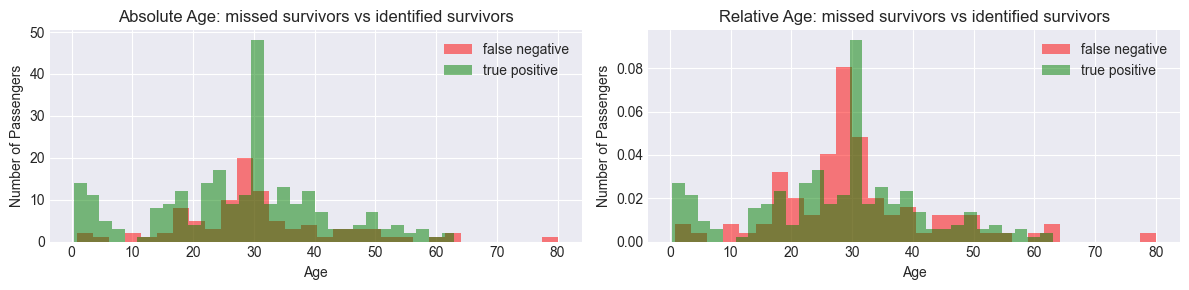

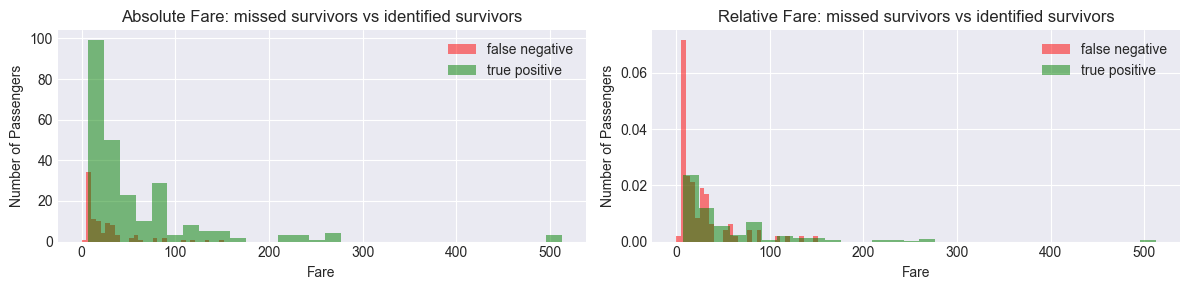

In [49]:
# plot continuous features against survival
for feature in ['Age', 'Fare']:
    # Create a figure with 2 subplots (1 row, 2 columns)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

    for ax, density, frequency in ((ax1, False, 'Absolute'), (ax2, True, 'Relative')):

        ax.hist(survive_catboost_fn[feature], bins=30, alpha=0.5, color='red', label='false negative', density=density)
        ax.hist(survive_catboost_tp[feature], bins=30, alpha=0.5, color='green', label='true positive', density=density)
        ax.set_title(f'{frequency} {feature}: missed survivors vs identified survivors')
        ax.set_ylabel('Number of Passengers')
        ax.set_xlabel(feature)
        ax.legend()

    plt.tight_layout() # Prevents labels from overlapping
    plt.show()

Zoom in on the 'Fare' range where the most missed survivors lie

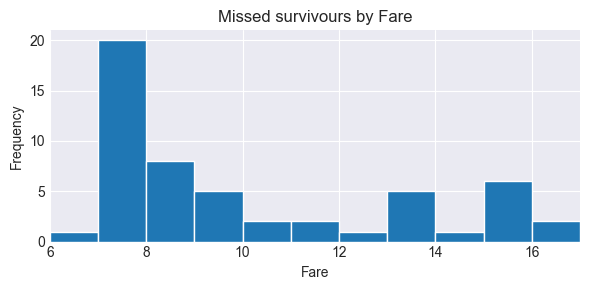

In [50]:
fig, ax = plt.subplots(figsize=(6, 3))

# define bin edges
bin_edges = range(4,18)


ax.hist(survive_catboost_fn['Fare'], bins=bin_edges, edgecolor='white')
ax.set(xlim=(6, 17),
       title='Missed survivours by Fare',
       xlabel='Fare',
       ylabel='Frequency')

plt.tight_layout()
plt.show()

Most of the missed survivors are on the lower end of feature fare, specially from 7 to 10 

In [51]:
# build a dataframe of passengers paying from 7 to 10 $
fare_7_to_8_df = eda2_df[(eda2_df['Fare'] >= 7) & (eda2_df['Fare'] <= 10)]


In [52]:
fare_7_to_8_df.describe()

,Age,Fare,SibSp,Parch,Pclass,Survived
count,308.000000,308.000000,308.000000,308.000000,308.0,308.000000
mean,28.309547,7.930626,0.084416,0.032468,3.0,0.211039
std,8.967090,0.593632,0.369017,0.211057,0.0,0.408710
min,0.420000,7.045800,0.000000,0.000000,3.0,0.000000
25%,22.000000,7.740650,0.000000,0.000000,3.0,0.000000
50%,29.699118,7.879200,0.000000,0.000000,3.0,0.000000
75%,29.699118,8.050000,0.000000,0.000000,3.0,0.000000
max,74.000000,9.845800,4.000000,2.000000,3.0,1.000000


### Feature engineering

In [ ]:
# extract title from Name feature
eda2_df['Title'] = (original_df['Name']
                    .str.extract(r'(Mr|Mrs|Master|Miss|Sir|Ms|Dr|Don|Rev)\.', expand=False)
                    .fillna('rare'))

# analyse the spread of titles
pd.crosstab(eda2_df['Survived'], eda2_df['Title'])

Title,Don,Dr,Master,Miss,Mr,Mrs,Ms,Rev,Sir,rare
Survived,,,,,,,,,,
0,1,4,17,55,436,26,0,6,0,4
1,0,3,23,127,81,99,1,0,1,7


Leaving categories with very few observations might lead to model overfitting. Group categories Don, Dr, Ms, Sir and rare. Even though the category Rev has only 6 observations, all individuals died, keep it as it looks like a strong signal.

### Apply column transformations v3


In [53]:
original_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [54]:
# custom function to use in column transformer preprocessor_v3 to obtain feature family size
def compute_family_size(df):
    fam_series = df['SibSp'] + df['Parch'] + 1
    return pd.DataFrame(fam_series) 

# provide a name for the family size column (since two columns go in but only one comes out, 'one-to-one' can't be used, a custom function must be defined)
def get_family_size_name(transformer, features):
        return ['family_size']

# pipeline to create title feature
title_transformer = Pipeline(steps=[
    ('extract', (FunctionTransformer(lambda x: x.iloc[:,0].str.extract(r'(Mr|Mrs|Master|Miss|Rev)\.'), feature_names_out='one-to-one'))),
    ('impute', SimpleImputer(strategy='constant', fill_value='rare'))          
])

preprocessor_v3 = ColumnTransformer(
    transformers= [
        ('title', title_transformer, ['Name']),
        ('age_scale', StandardScaler(), ['Age']),
        ('fare_transform', PowerTransformer(), ['Fare']),
        ('family_size', FunctionTransformer(compute_family_size, feature_names_out=get_family_size_name), ['SibSp', 'Parch']),
        ('drop_columns', 'drop', ['PassengerId', 'Survived', 'Ticket', 'Name'])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
    n_jobs=-1    
)

preprocessor_v3.set_output(transform='pandas')

transform_pipeline_v3 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('preprocessor_v3', preprocessor_v3)
])

transformed_df_v3 = transform_pipeline_v3.fit_transform(original_df)

transformed_df_v3_columns = transform_pipeline_v3.get_feature_names_out()